# 02. 저위험 이상현상 검증 (Low-Risk Anomaly Verification)

## 검증 목표
미국 S&P500 시장에서 **저위험 주식이 고위험 주식보다 위험 대비 수익이 높은지** 확인한다.

## 검증 방법
**포트폴리오 정렬 (Portfolio Sort)**: beta/vol 기준 5분위 정렬 → 분위별 수익률 비교

## 결과
- 저변동성(Q1) 포트폴리오가 고변동성(Q5)보다 누적 수익률 높음

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import io
import re
import zipfile
import requests
import platform
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / 'data'
OUT_DIR   = BASE_DIR / 'outputs' / '02_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PATH = DATA_DIR / 'monthly_panel.csv'
assert PANEL_PATH.exists(), '01_DataCollection.ipynb 먼저 실행하세요'

monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
monthly_df = monthly_df.set_index(['date', 'ticker'])

print(f'패널 로드: {monthly_df.shape}')
print(f'기간: {monthly_df.index.get_level_values("date").min().date()} ~ {monthly_df.index.get_level_values("date").max().date()}')
print(f'종목 수: {monthly_df.index.get_level_values("ticker").nunique()}')

패널 로드: (108180, 11)
기간: 2004-01-31 ~ 2025-12-31
종목 수: 621


=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===

월별 종목 수 요약:
  평균: 410개  |  최소: 330개  |  최대: 500개

[연도별 평균 종목 수]
  2004: 332개
  2005: 334개
  2006: 339개
  2007: 343개
  2008: 351개
  2009: 356개
  2010: 358개
  2011: 364개
  2012: 376개
  2013: 389개
  2014: 396개
  2015: 408개
  2016: 429개
  2017: 442개
  2018: 447개
  2019: 452개
  2020: 464개
  2021: 471개
  2022: 479개
  2023: 488개
  2024: 491개
  2025: 496개

[샘플 월 편입 종목 예시]
  2004-01-31: 330종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2009-01-31: 354종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2014-01-31: 394종목  → 예시: ['A', 'AA', 'AAPL', 'ABBV', 'ABT']
  2019-01-31: 448종목  → 예시: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV']
  2025-12-31: 500종목  → 예시: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']


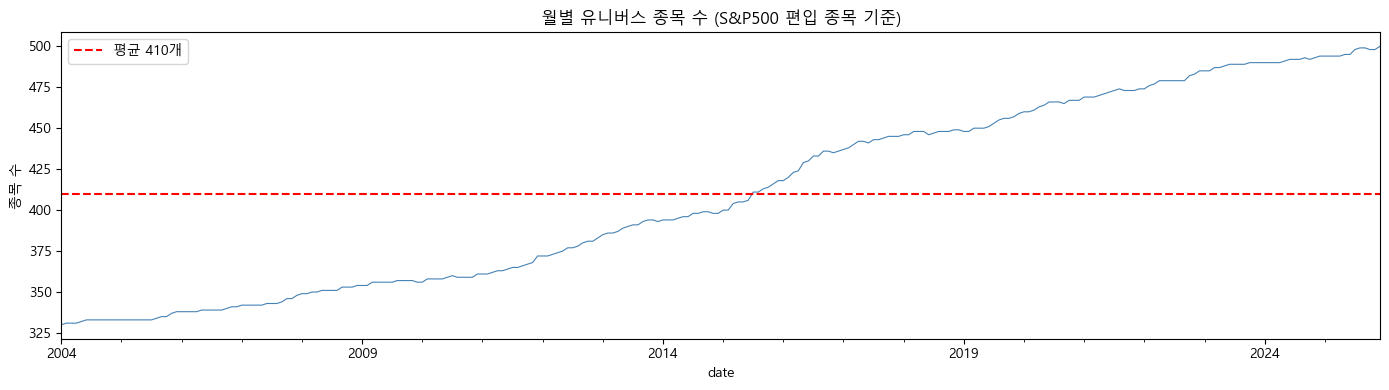

In [2]:
# ── 멤버십 필터링 검증: 실제로 당시 S&P500 편입 종목만 포함되는지 ──
print("=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===\n")

monthly_counts = monthly_df.groupby(level='date').size()
print(f"월별 종목 수 요약:")
print(f"  평균: {monthly_counts.mean():.0f}개  |  최소: {monthly_counts.min()}개  |  최대: {monthly_counts.max()}개\n")

print("[연도별 평균 종목 수]")
yearly = monthly_counts.groupby(monthly_counts.index.year).mean().astype(int)
for yr, cnt in yearly.items():
    print(f"  {yr}: {cnt}개")

print("\n[샘플 월 편입 종목 예시]")
sample_dates = monthly_counts.index[[0, 60, 120, 180, -1]]
for d in sample_dates:
    tickers = monthly_df.loc[d].index.tolist()
    print(f"  {d.date()}: {len(tickers)}종목  → 예시: {tickers[:5]}")

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.axhline(monthly_counts.mean(), color='red', linestyle='--',
           label=f'평균 {monthly_counts.mean():.0f}개')
ax.set_title('월별 유니버스 종목 수 (S&P500 편입 종목 기준)')
ax.set_ylabel('종목 수')
ax.legend()
plt.tight_layout()
plt.show()

=== 기술통계 ===
            ret_1m    beta_252d     vol_252d
count  107811.0000  106230.0000  106230.0000
mean        0.0109       1.0080       0.3091
std         0.0906       0.4127       0.1708
min        -0.8435      -1.6580       0.0905
1%         -0.2263       0.1029       0.1297
5%         -0.1243       0.3759       0.1531
25%        -0.0365       0.7455       0.2066
50%         0.0114       0.9857       0.2654
75%         0.0568       1.2418       0.3589
95%         0.1444       1.7124       0.5949
99%         0.2548       2.1589       0.9692
max         2.4498       3.9243       2.8059

=== 극단값 확인 ===

[ret_1m]
  min=-0.8435  max=2.4498
  1%=-0.2263  99%=0.2548
  1~99% 밖 관측 수: 2158개 (2.0%)

[beta_252d]
  min=-1.6580  max=3.9243
  1%=0.1029  99%=2.1589
  1~99% 밖 관측 수: 2126개 (2.0%)

[vol_252d]
  min=0.0905  max=2.8059
  1%=0.1297  99%=0.9692
  1~99% 밖 관측 수: 2126개 (2.0%)

=== ret_1m 최대값 상위 10개 ===
date        ticker
2009-08-31  AIG       2.449771
2010-02-28  GR        2.333333
2020-0

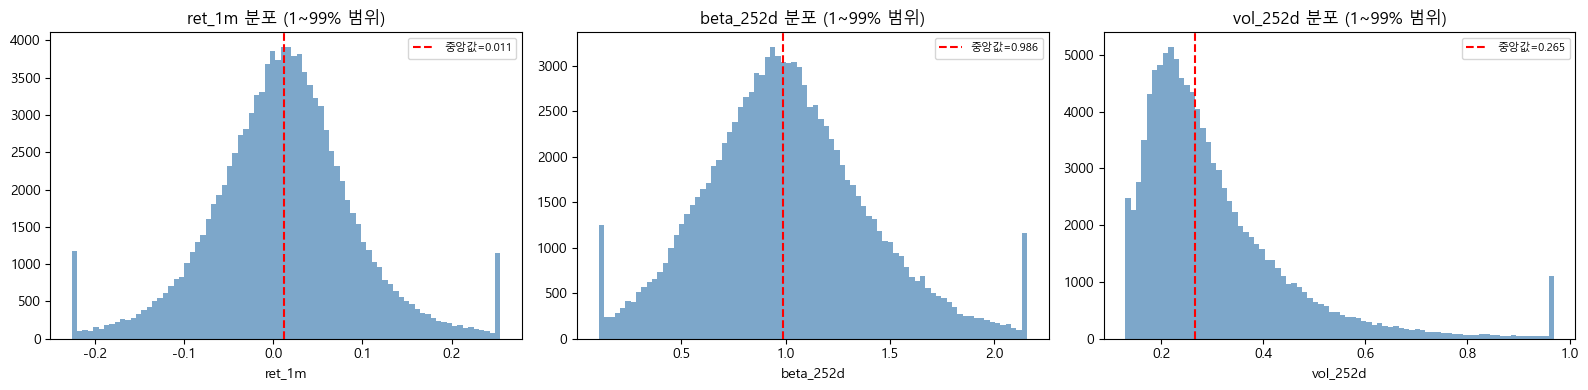

In [3]:
# ── 주요 변수 분포 확인 (포트폴리오 정렬 전) ─────────────────
cols = ['ret_1m', 'beta_252d', 'vol_252d']

print("=== 기술통계 ===")
print(monthly_df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).round(4))

print("\n=== 극단값 확인 ===")
for col in cols:
    s = monthly_df[col].dropna()
    print(f"\n[{col}]")
    print(f"  min={s.min():.4f}  max={s.max():.4f}")
    print(f"  1%={s.quantile(0.01):.4f}  99%={s.quantile(0.99):.4f}")
    n_extreme = ((s < s.quantile(0.01)) | (s > s.quantile(0.99))).sum()
    print(f"  1~99% 밖 관측 수: {n_extreme}개 ({n_extreme/len(s):.1%})")

# ── 극단값 원인 확인: ret_1m 상위/하위 10개 ───────────────
print("\n=== ret_1m 최대값 상위 10개 ===")
print(monthly_df['ret_1m'].nlargest(10))

print("\n=== ret_1m 최솟값 하위 10개 ===")
print(monthly_df['ret_1m'].nsmallest(10))

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cols):
    s = monthly_df[col].dropna()
    p1, p99 = s.quantile(0.01), s.quantile(0.99)
    ax.hist(s.clip(p1, p99), bins=80, color='steelblue', alpha=0.7)
    ax.set_title(f'{col} 분포 (1~99% 범위)')
    ax.set_xlabel(col)
    ax.axvline(s.median(), color='red', linestyle='--', label=f'중앙값={s.median():.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 1. 포트폴리오 정렬 (Portfolio Sort)

## 방법
매월 말 시점에 `beta_252d` 기준으로 5분위 정렬:
- **Q1**: 저베타 (저위험)
- **Q5**: 고베타 (고위험)

각 분위에서 동일가중(Equal-Weight) 포트폴리오를 구성하고 다음 달 수익률(`ret_1m`)을 측정한다.

**Look-ahead bias 방지**: 당월 말 beta로 분류 → 다음 달 수익률 측정 (이미 `ret_1m`에 반영)

In [4]:
def portfolio_sort(df, sort_col, ret_col='ret_1m', n_quantiles=5):
    """
    매월 sort_col 기준으로 n_quantiles 분위 포트폴리오 구성.
    각 분위의 동일가중 수익률 반환.
    """
    results = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < n_quantiles * 5:  # 분위당 최소 5종목
            continue
        try:
            labels = list(range(1, n_quantiles + 1))
            valid['quintile'] = pd.qcut(valid[sort_col], n_quantiles,
                                        labels=labels, duplicates='drop')
            port_ret = valid.groupby('quintile')[ret_col].mean()
            port_ret.name = date
            results.append(port_ret)
        except Exception as e:
            print(f"  [{date.date()}] 스킵: {e}")
            continue
    return pd.DataFrame(results)


# 베타 기준 포트폴리오
beta_ports = portfolio_sort(monthly_df, 'beta_252d')
# 변동성 기준 포트폴리오
vol_ports  = portfolio_sort(monthly_df, 'vol_252d')

# 무위험수익률 (월별)
rf_monthly = monthly_df['rf_1m'].groupby(level='date').first()

print(f'베타 포트폴리오: {beta_ports.shape[0]}개월 × {beta_ports.shape[1]}분위')
print(f'변동성 포트폴리오: {vol_ports.shape[0]}개월 × {vol_ports.shape[1]}분위')

베타 포트폴리오: 259개월 × 5분위
변동성 포트폴리오: 259개월 × 5분위


In [5]:
# duplicates로 제거되는 분위 수가 있는지 확인
print(beta_ports.isna().sum())

quintile
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [6]:
ANN = np.sqrt(12)  # 월별 → 연환산

def performance_summary(port_df, rf_series, label='베타'):
    """분위별 연환산 수익률, 변동성, Sharpe Ratio 계산"""
    rf_aligned = rf_series.reindex(port_df.index)
    rows = []
    for q in port_df.columns:
        r = port_df[q].dropna()
        rf = rf_aligned.reindex(r.index)
        excess = r - rf
        ann_ret  = r.mean() * 12
        ann_vol  = r.std() * ANN
        sr       = excess.mean() / excess.std() * ANN
        cum_ret  = (1 + r).prod() - 1
        rows.append({
            f'{label} 분위': f'Q{q}',
            '연환산 수익률': f'{ann_ret:.2%}',
            '연환산 변동성': f'{ann_vol:.2%}',
            'Sharpe Ratio':  f'{sr:.3f}',
            '누적 수익률':    f'{cum_ret:.2%}',
        })
    return pd.DataFrame(rows).set_index(f'{label} 분위')

print('=== 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports, rf_monthly, '베타'))
print('\n=== 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports, rf_monthly, '변동성'))

=== 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio    누적 수익률
베타 분위                                       
Q1     10.79%  11.09%        0.821   790.57%
Q2     11.97%  13.37%        0.769   979.99%
Q3     12.92%  16.99%        0.662  1071.79%
Q4     14.26%  20.36%        0.618  1270.46%
Q5     15.37%  26.96%        0.508  1131.20%

=== 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio    누적 수익률
변동성 분위                                       
Q1      12.16%  11.05%        0.946  1094.63%
Q2      11.70%  13.74%        0.729   907.79%
Q3      12.76%  16.67%        0.665  1046.57%
Q4      12.66%  19.73%        0.557   897.52%
Q5      16.01%  26.82%        0.535  1327.62%


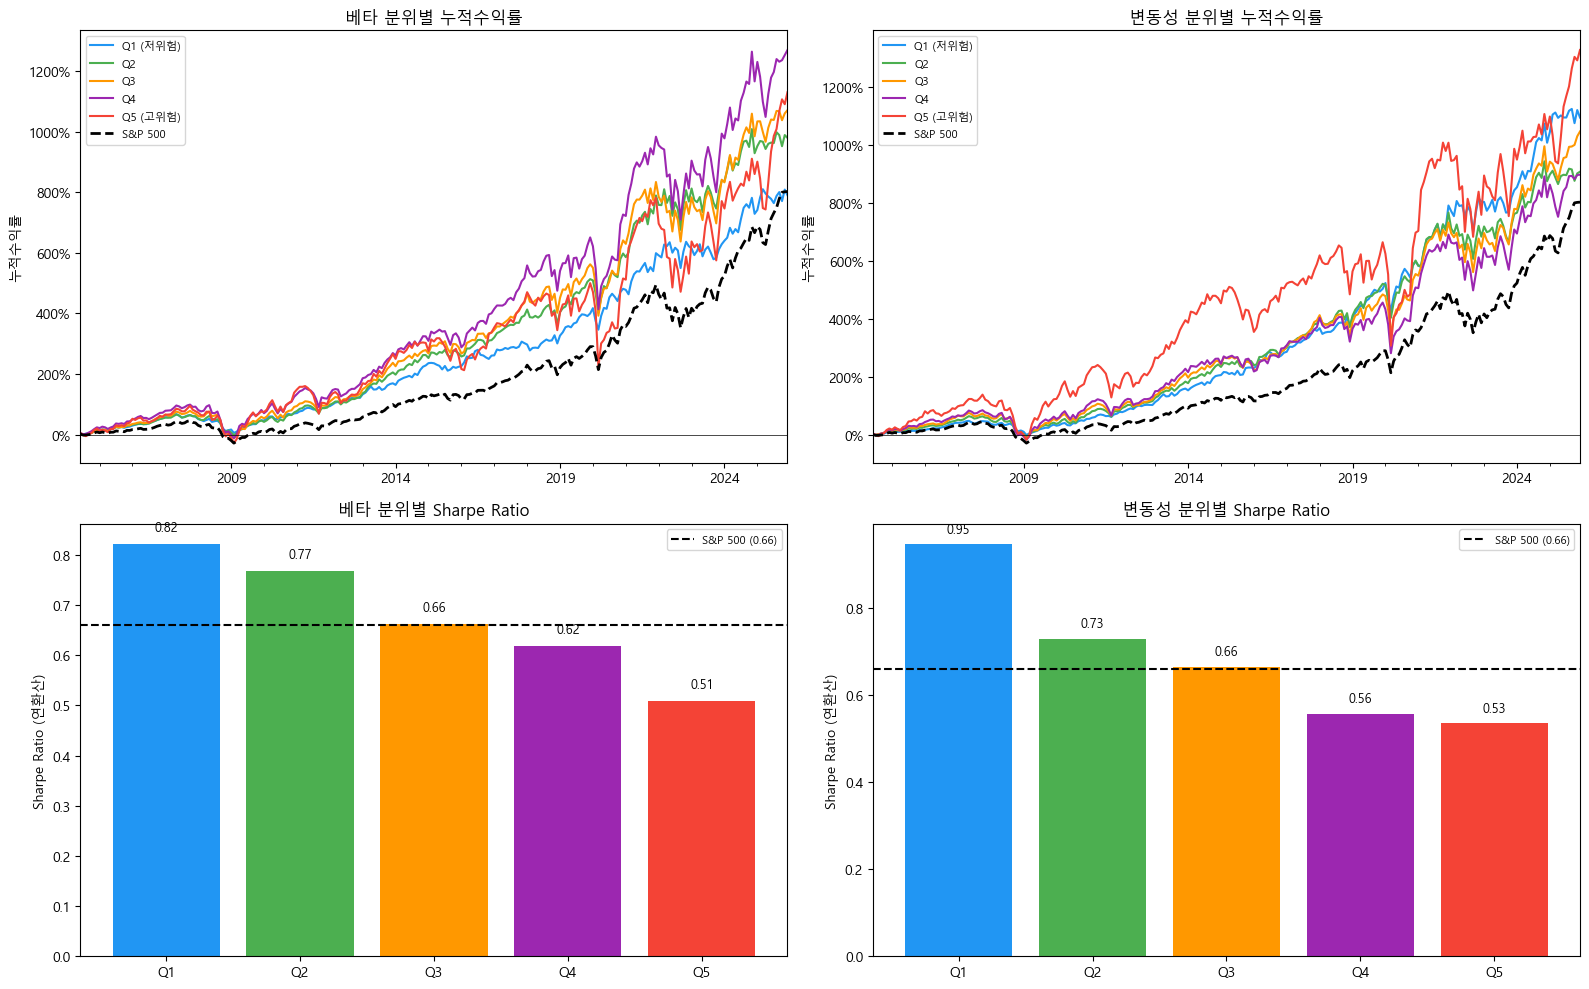

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

rf_aligned_beta = rf_monthly.reindex(beta_ports.index)
rf_aligned_vol  = rf_monthly.reindex(vol_ports.index)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
labels = ['Q1 (저위험)', 'Q2', 'Q3', 'Q4', 'Q5 (고위험)']

# SPY 벤치마크 누적수익률
spy_monthly = monthly_df['spy_ret'].groupby(level='date').first()
spy_cum = (1 + spy_monthly).cumprod() - 1

# ── 누적수익률 (베타) ─────────────────────────────────────
ax = axes[0, 0]
for i, q in enumerate(beta_ports.columns):
    cum = (1 + beta_ports[q].dropna()).cumprod() - 1
    cum.plot(ax=ax, label=labels[i], color=colors[i])
spy_cum.reindex(beta_ports.index).plot(ax=ax, label='S&P 500', color='black',
                                        linestyle='--', linewidth=2)
ax.set_title('베타 분위별 누적수익률')
ax.set_ylabel('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

# ── 누적수익률 (변동성) ───────────────────────────────────
ax = axes[0, 1]
for i, q in enumerate(vol_ports.columns):
    cum = (1 + vol_ports[q].dropna()).cumprod() - 1
    cum.plot(ax=ax, label=labels[i], color=colors[i])
spy_cum.reindex(vol_ports.index).plot(ax=ax, label='S&P 500', color='black',
                                       linestyle='--', linewidth=2)
ax.set_title('변동성 분위별 누적수익률')
ax.set_ylabel('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

# ── Sharpe Ratio 비교 (베타) ──────────────────────────────
ax = axes[1, 0]
sr_beta = [(beta_ports[q] - rf_aligned_beta).mean() /
           (beta_ports[q] - rf_aligned_beta).std() * ANN
           for q in beta_ports.columns]
spy_sr_beta = (spy_monthly.reindex(beta_ports.index) - rf_aligned_beta).mean() / \
              (spy_monthly.reindex(beta_ports.index) - rf_aligned_beta).std() * ANN
bars = ax.bar([f'Q{q}' for q in beta_ports.columns], sr_beta, color=colors)
ax.axhline(spy_sr_beta, color='black', linestyle='--', linewidth=1.5,
           label=f'S&P 500 ({spy_sr_beta:.2f})')
ax.set_title('베타 분위별 Sharpe Ratio')
ax.set_ylabel('Sharpe Ratio (연환산)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)
for bar, val in zip(bars, sr_beta):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# ── Sharpe Ratio 비교 (변동성) ────────────────────────────
ax = axes[1, 1]
sr_vol = [(vol_ports[q] - rf_aligned_vol).mean() /
          (vol_ports[q] - rf_aligned_vol).std() * ANN
          for q in vol_ports.columns]
spy_sr_vol = (spy_monthly.reindex(vol_ports.index) - rf_aligned_vol).mean() / \
             (spy_monthly.reindex(vol_ports.index) - rf_aligned_vol).std() * ANN
bars = ax.bar([f'Q{q}' for q in vol_ports.columns], sr_vol, color=colors)
ax.axhline(spy_sr_vol, color='black', linestyle='--', linewidth=1.5,
           label=f'S&P 500 ({spy_sr_vol:.2f})')
ax.set_title('변동성 분위별 Sharpe Ratio')
ax.set_ylabel('Sharpe Ratio (연환산)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)
for bar, val in zip(bars, sr_vol):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort.png', dpi=150, bbox_inches='tight')
plt.show()

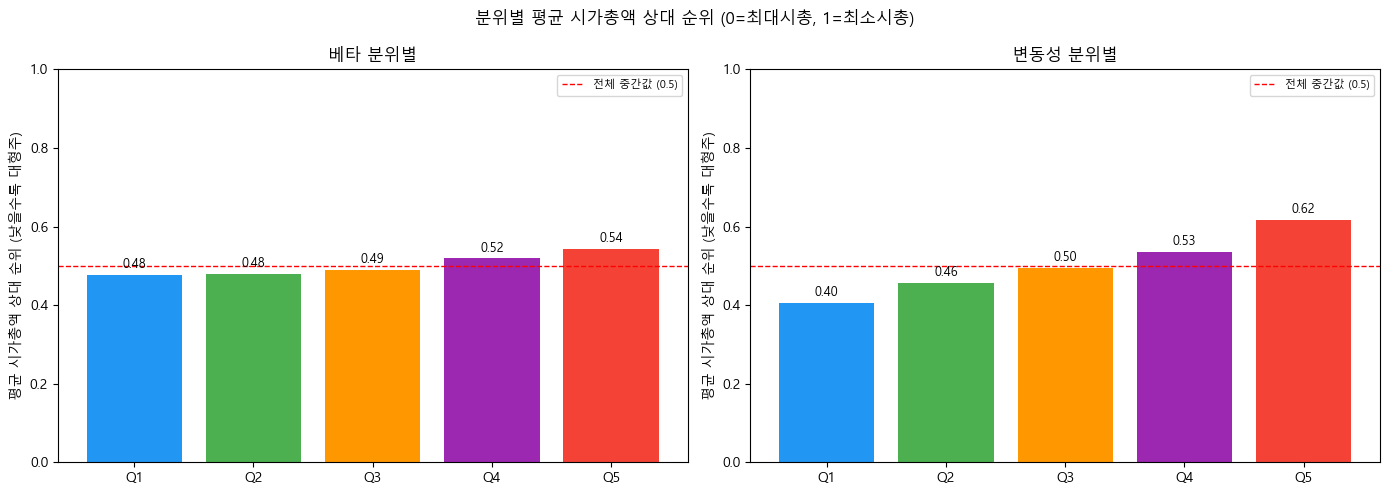


=== Q별 평균 시가총액 상대 순위 (전체 기간) ===
(0에 가까울수록 대형주, 1에 가까울수록 소형주)

[베타 기준]  Q1: 0.48  Q2: 0.48  Q3: 0.49  Q4: 0.52  Q5: 0.54

[변동성 기준]  Q1: 0.40  Q2: 0.46  Q3: 0.50  Q4: 0.53  Q5: 0.62


In [8]:
# ── Q별 평균 시가총액 순위: 저위험 분위일수록 대형주인가? ────────
def quintile_mcap_rank(df, sort_col):
    rows = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, 'log_mcap']].dropna()
        if len(valid) < 25:
            continue
        try:
            valid = valid.copy()
            valid['quintile'] = pd.qcut(valid[sort_col], 5,
                                        labels=[1, 2, 3, 4, 5], duplicates='drop')
            # 0~1 정규화 순위 (0 = 최대 시총, 1 = 최소 시총)
            # pct=True로 월별 종목 수 변화에 무관하게 비교 가능
            valid['mcap_rank'] = valid['log_mcap'].rank(ascending=False, pct=True)
            for q, grp in valid.groupby('quintile'):
                rows.append({'date': date, 'quintile': int(q),
                             'avg_rank': grp['mcap_rank'].mean()})
        except Exception:
            continue
    return pd.DataFrame(rows)

rank_beta = quintile_mcap_rank(monthly_df, 'beta_252d')
rank_vol  = quintile_mcap_rank(monthly_df, 'vol_252d')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('분위별 평균 시가총액 상대 순위 (0=최대시총, 1=최소시총)', fontsize=12)

for ax, rank_df, title in [
    (axes[0], rank_beta, '베타 분위별'),
    (axes[1], rank_vol,  '변동성 분위별'),
]:
    avg = rank_df.groupby('quintile')['avg_rank'].mean()
    bars = ax.bar([f'Q{q}' for q in avg.index], avg.values, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel('평균 시가총액 상대 순위 (낮을수록 대형주)')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='전체 중간값 (0.5)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'quintile_mcap_rank.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Q별 평균 시가총액 상대 순위 (전체 기간) ===")
print("(0에 가까울수록 대형주, 1에 가까울수록 소형주)")
for title, rank_df in [('베타 기준', rank_beta), ('변동성 기준', rank_vol)]:
    avg = rank_df.groupby('quintile')['avg_rank'].mean()
    print(f"\n[{title}]  {'  '.join(f'Q{q}: {v:.2f}' for q, v in avg.items())}")

=== [2016~2025] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
베타 분위                                      
Q1     10.86%  11.95%        0.729  174.88%
Q2     11.77%  13.94%        0.690  193.21%
Q3     12.51%  16.84%        0.616  201.58%
Q4     13.87%  20.00%        0.587  225.78%
Q5     16.30%  27.65%        0.513  242.46%

=== [2016~2025] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
변동성 분위                                      
Q1      13.58%  12.11%        0.943  259.28%
Q2      11.49%  14.23%        0.657  184.12%
Q3      13.41%  16.33%        0.691  232.74%
Q4      12.46%  19.45%        0.531  186.45%
Q5      14.35%  26.91%        0.454  187.03%


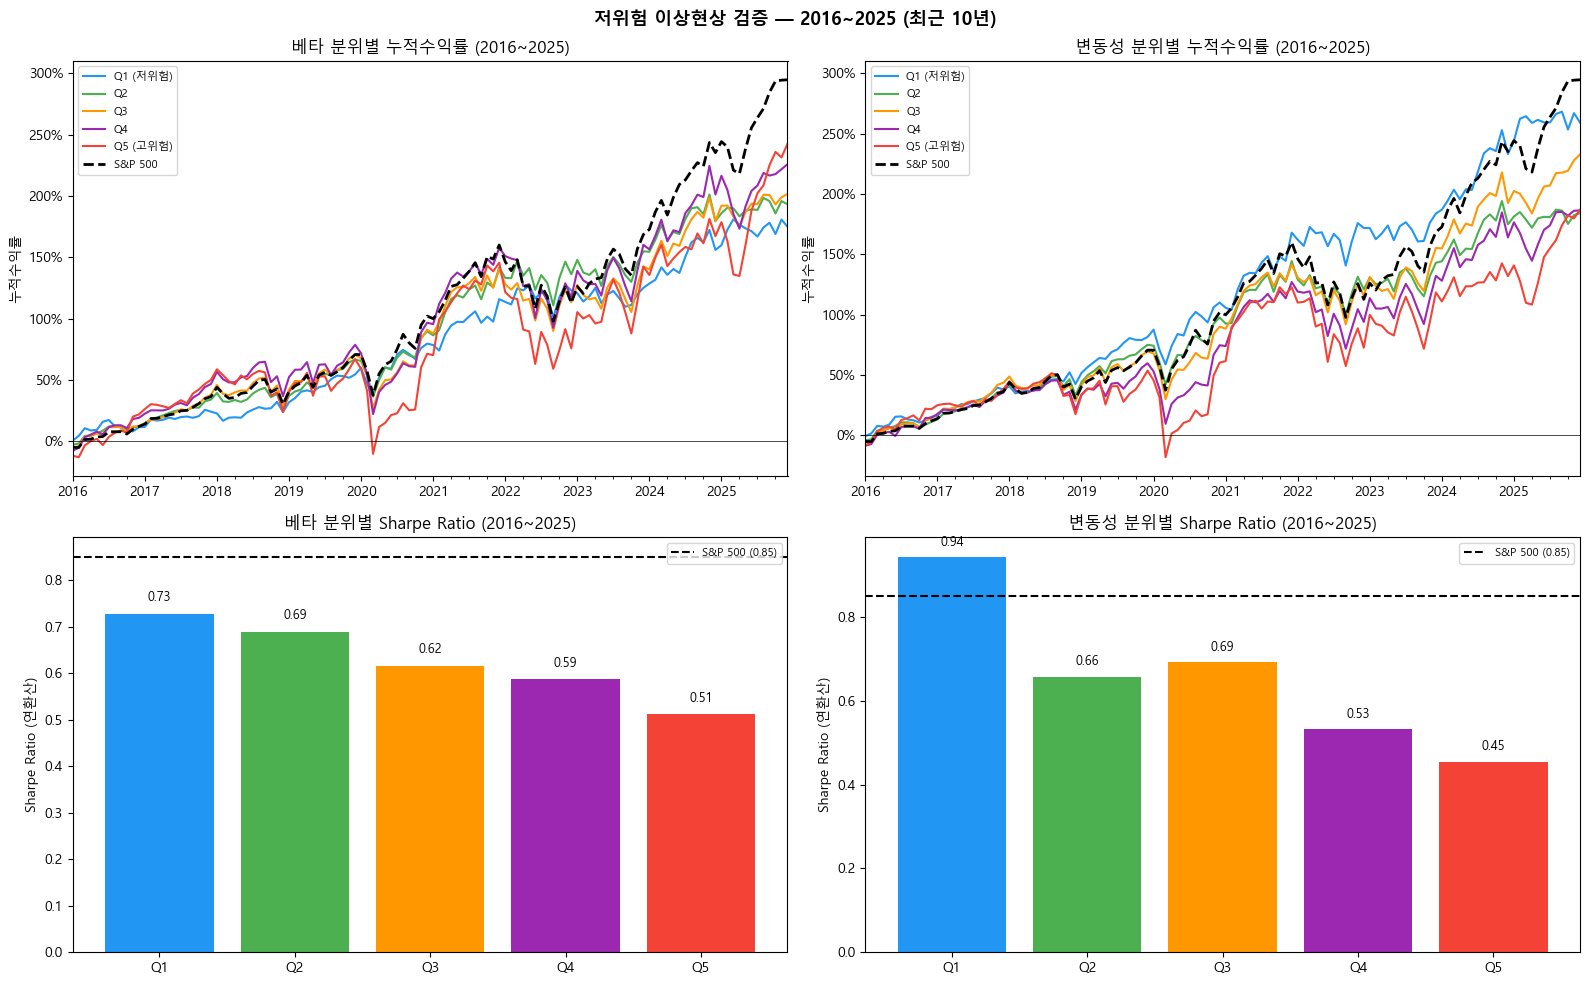

In [9]:
# ── 2016~2025 구간 분석 ──────────────────────────────────────
START_RECENT = '2016-01-01'

df_recent     = monthly_df[monthly_df.index.get_level_values('date') >= START_RECENT]
beta_ports_16 = portfolio_sort(df_recent, 'beta_252d')
vol_ports_16  = portfolio_sort(df_recent, 'vol_252d')
rf_monthly_16 = rf_monthly[rf_monthly.index >= START_RECENT]

print('=== [2016~2025] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_16, rf_monthly_16, '베타'))
print('\n=== [2016~2025] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_16, rf_monthly_16, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('저위험 이상현상 검증 — 2016~2025 (최근 10년)', fontsize=13, fontweight='bold')

rf_b16 = rf_monthly_16.reindex(beta_ports_16.index)
rf_v16 = rf_monthly_16.reindex(vol_ports_16.index)
spy_16 = spy_monthly[spy_monthly.index >= START_RECENT]
spy_cum_16 = (1 + spy_16).cumprod() - 1

# 누적수익률 (베타)
ax = axes[0, 0]
for i, q in enumerate(beta_ports_16.columns):
    cum = (1 + beta_ports_16[q].dropna()).cumprod() - 1
    cum.plot(ax=ax, label=labels[i], color=colors[i])
spy_cum_16.reindex(beta_ports_16.index).plot(ax=ax, label='S&P 500',
                                              color='black', linestyle='--', linewidth=2)
ax.set_title('베타 분위별 누적수익률 (2016~2025)')
ax.set_ylabel('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

# 누적수익률 (변동성)
ax = axes[0, 1]
for i, q in enumerate(vol_ports_16.columns):
    cum = (1 + vol_ports_16[q].dropna()).cumprod() - 1
    cum.plot(ax=ax, label=labels[i], color=colors[i])
spy_cum_16.reindex(vol_ports_16.index).plot(ax=ax, label='S&P 500',
                                             color='black', linestyle='--', linewidth=2)
ax.set_title('변동성 분위별 누적수익률 (2016~2025)')
ax.set_ylabel('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

# Sharpe (베타)
ax = axes[1, 0]
sr_b16 = [(beta_ports_16[q] - rf_b16).mean() /
           (beta_ports_16[q] - rf_b16).std() * ANN
           for q in beta_ports_16.columns]
spy_sr_b16 = (spy_16.reindex(beta_ports_16.index) - rf_b16).mean() / \
             (spy_16.reindex(beta_ports_16.index) - rf_b16).std() * ANN
bars = ax.bar([f'Q{q}' for q in beta_ports_16.columns], sr_b16, color=colors)
ax.axhline(spy_sr_b16, color='black', linestyle='--', linewidth=1.5,
           label=f'S&P 500 ({spy_sr_b16:.2f})')
ax.set_title('베타 분위별 Sharpe Ratio (2016~2025)')
ax.set_ylabel('Sharpe Ratio (연환산)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)
for bar, val in zip(bars, sr_b16):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Sharpe (변동성)
ax = axes[1, 1]
sr_v16 = [(vol_ports_16[q] - rf_v16).mean() /
           (vol_ports_16[q] - rf_v16).std() * ANN
           for q in vol_ports_16.columns]
spy_sr_v16 = (spy_16.reindex(vol_ports_16.index) - rf_v16).mean() / \
             (spy_16.reindex(vol_ports_16.index) - rf_v16).std() * ANN
bars = ax.bar([f'Q{q}' for q in vol_ports_16.columns], sr_v16, color=colors)
ax.axhline(spy_sr_v16, color='black', linestyle='--', linewidth=1.5,
           label=f'S&P 500 ({spy_sr_v16:.2f})')
ax.set_title('변동성 분위별 Sharpe Ratio (2016~2025)')
ax.set_ylabel('Sharpe Ratio (연환산)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)
for bar, val in zip(bars, sr_v16):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2016.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. 결과 요약

아래 셀을 실행하면 주요 검증 결과를 한눈에 정리해줍니다.

In [10]:
print('=' * 55)
print('저위험 이상현상 검증 결과 요약')
print('=' * 55)

rf_b = rf_monthly.reindex(beta_ports.index)
rf_v = rf_monthly.reindex(vol_ports.index)

sr_beta = {q: (beta_ports[q] - rf_b).mean() / (beta_ports[q] - rf_b).std() * ANN
           for q in beta_ports.columns}
sr_vol  = {q: (vol_ports[q]  - rf_v).mean()  / (vol_ports[q]  - rf_v).std()  * ANN
           for q in vol_ports.columns}

print(f'\n[베타 기준]  Q1 SR: {sr_beta[1]:.3f}  →  Q5 SR: {sr_beta[5]:.3f}  '
      f'스프레드: {sr_beta[1]-sr_beta[5]:.3f}  '
      f'→ {"저위험 이상현상 확인 ✓" if sr_beta[1] > sr_beta[5] else "미확인 ✗"}')

print(f'\n[변동성 기준]  Q1 SR: {sr_vol[1]:.3f}  →  Q5 SR: {sr_vol[5]:.3f}  '
      f'스프레드: {sr_vol[1]-sr_vol[5]:.3f}  '
      f'→ {"저위험 이상현상 확인 ✓" if sr_vol[1] > sr_vol[5] else "미확인 ✗"}')

print('\n' + '=' * 55)

저위험 이상현상 검증 결과 요약

[베타 기준]  Q1 SR: 0.821  →  Q5 SR: 0.508  스프레드: 0.313  → 저위험 이상현상 확인 ✓

[변동성 기준]  Q1 SR: 0.946  →  Q5 SR: 0.535  스프레드: 0.411  → 저위험 이상현상 확인 ✓

